<a href="https://colab.research.google.com/github/mihikag-tech/UTD-Deep-Dive-AI-Project/blob/test/XGB_troubleshoot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import pickle

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("/content/Combined_dataset_model.csv")
df = pd.get_dummies(df, columns=["biome"], dtype=int)
df = df.drop(columns=['Unnamed: 0'])
print(df.columns)


Index(['county', 'land_area', 'tc_goal', 'treecanopy', 'tc_gap', 'priority_i',
       'pctpocnorm', 'pctpovnorm', 'unemplnorm', 'dep_perc', 'depratnorm',
       'health_nor', 'temp_norm', 'tes', 'tesctyscor', 'rank', 'rankgrpsz',
       'Mean_Temp', 'Median_Temp', 'STD_Temp', 'Min_Temp', 'Max_Temp',
       'Mean_Rain', 'Median_Rain', 'STD_Rain', 'Min_Rain', 'Max_Rain',
       'biome_Desert', 'biome_Forest', 'biome_Grassland'],
      dtype='object')


In [ ]:
features = ['land_area', 'treecanopy', 'tc_gap',
       'priority_i', 'pctpocnorm', 'pctpovnorm', 'unemplnorm', 'dep_perc',
       'depratnorm', 'health_nor', 'tes', 'tesctyscor', 'rank',
       'rankgrpsz', 'Mean_Temp', 'Median_Temp', 'STD_Temp', 'Min_Temp',
       'Max_Temp', 'Mean_Rain', 'Median_Rain', 'STD_Rain', 'Min_Rain',
       'Max_Rain']
target = ['temp_norm']
X_df = df[features]
y_df = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, random_state = 42)

In [ ]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
}

grid_search = GridSearchCV(
    XGBRegressor(random_state = 42, objective='reg:squarederror'),
    param_grid,
    cv = 5,
    scoring = 'r2'
)

grid_search.fit(X_train, y_train)

print("Best params :", grid_search.best_params_)
print("Best CV acc :", round(grid_search.best_score_, 4))
print("Test acc    :", round(grid_search.best_estimator_.score(X_test, y_test), 4))

Best params : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best CV acc : 0.7178
Test acc    : 0.721


In [ ]:
best_model = grid_search.best_estimator_
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
model = best_model
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

print("R2 score:", r2_score(y_test, model_pred))
print("MAE:", mean_absolute_error(y_test, model_pred))




R2 score: 0.7209781408309937
MAE: 0.0701315701007843


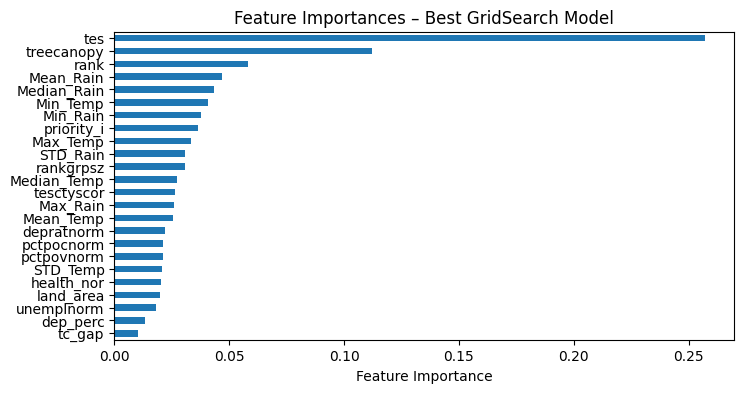

In [ ]:
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values()

plt.figure(figsize = (8, 4))
feat_imp.plot(kind = 'barh')
plt.xlabel("Feature Importance")
plt.title("Feature Importances – Best GridSearch Model")
plt.show()


In [ ]:
solution_costs = pd.read_csv("/content/Green Intervention Budgets - Sheet1.csv")

In [ ]:
# Define what each solution actually changes, and by how much
solution_effects = {
    "green_street": {
        "treecanopy": 1.10,
        "Mean_Temp": 1.15,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Street"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Street"]["avg_sq_feet"].iloc[0])


    },

    "green_parking_lot": {
        "treecanopy": 1.06,
        "Mean_Temp": 1.09,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Parking Lot"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Parking Lot"]["avg_sq_feet"].iloc[0])

    },

    "urban_forest": {
        "treecanopy": 1.2,
        "Mean_Temp": 1.03,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Urban Forest"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Urban Forest"]["avg_sq_feet"].iloc[0])

    },

    "green_roof": {
        "treecanopy": 1.05,
        "Mean_Temp": 1.01,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Roof"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Roof"]["avg_sq_feet"].iloc[0])
    },

    "green_belt": {
        "treecanopy": 1.2,
        "Mean_Temp": 1.1,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Belt"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Belt"]["avg_sq_feet"].iloc[0])
    },

    "park": {
        "treecanopy": 1.14,
        "Mean_Temp": 1.01,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Park"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Park"]["avg_sq_feet"].iloc[0])
    },

    "garden": {
        "treecanopy": 1.03,
        "Mean_Temp": 1.06,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Garden"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Garden"]["avg_sq_feet"].iloc[0])
    }

}

solution_effects = pd.DataFrame(solution_effects)
solution_effects = solution_effects.T
solution_effects.head()

,treecanopy,Mean_Temp,Cost
green_street,1.10,1.15,60000.0
green_parking_lot,1.06,1.09,300000.0
urban_forest,1.20,1.03,500000.0
green_roof,1.05,1.01,200000.0
green_belt,1.20,1.10,750000.0


In [ ]:
def impact_calc(model, county, solutions, feature_cols):
  impact_df = []
  county_df = df[df["county"] == county]
  for row in county_df:
    prediction = model.predict(row)
    for solution in solution_effects[solution].items():
      for key, value in solution_effects[solution].items():
        county_df[key] = county_df[key] + value

    update_prediction = model.predict(row)
    pct_temp_chg = update_prediction/prediction
    impact_df.concat(county, solution, pct_temp_chg)
  return impact_df


test = impact_calc(model, "Austin County", solution_effects, )

In [ ]:
def impact_calc(model, county, solutions_dict, feature_cols):
  impact_results = [] # To store results
  county_df_filtered = df[df["county"] == county]

  for index, row_data in county_df_filtered.iterrows():
    # Get prediction
    original_features = row_data[feature_cols]
    prediction_original = model.predict(pd.DataFrame([original_features]))[0]

    for solution_name, effects in solutions_dict.iterrows(): # Iterate through solutions and their effects
      modified_features = original_features.copy() # Create a copy to modify
      for key, value in effects.items(): # Apply effects
        if key in modified_features.index:
          modified_features[key] *= value
        #else:
          #print("Warning: Feature", key, "from solution", solution_name, "not found in model features. Skipping update for this feature.")

      # Predict with modified features
      prediction_modified = model.predict(pd.DataFrame([modified_features]))[0]

      # Calculate change
      pct_temp_chg = (prediction_modified - prediction_original) / prediction_original if prediction_original != 0 else 0

      impact_results.append({
          "county": county,
          "row_index": index,
          "solution": solution_name,
          "original_temp_norm_pred": prediction_original,
          "modified_temp_norm_pred": prediction_modified,
          "pct_temp_change": pct_temp_chg
      })
  return impact_results


result = impact_calc(model, "Austin County", solution_effects, features)
pd.DataFrame(result)
result

[{'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_street',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.4204291),
  'pct_temp_change': np.float32(-0.13615505)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_parking_lot',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.42726064),
  'pct_temp_change': np.float32(-0.122118495)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'urban_forest',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.45442554),
  'pct_temp_change': np.float32(-0.066303454)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_roof',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.50671697),
  'pct_temp_change': np.float32(0.041138396)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_be

In [ ]:
def impact_calc(model, county, solution_effects, features):
    county_df = df[df["county"] == county]
    final_results = []

    for row_idx, row_data in county_df.iterrows():
        baseline = row_data[features]
        prediction = model.predict(pd.DataFrame([baseline]))[0]

        # Initialize dictionary for the current row
        row_output = {
            "county": county,
            "original_temp": prediction
        }

        for solution_name, effects_series in solution_effects.iterrows():
            modified = baseline.copy()
            for feature_key, multiplier in effects_series.items():
                # Only modify features that are in the model's feature list and are not 'Cost'
                if feature_key in features and feature_key != 'Cost':
                    modified[feature_key] = modified[feature_key] * multiplier

            update_prediction = model.predict(pd.DataFrame([modified]))[0]
            pct_temp_norm_chg = ((update_prediction - prediction) / prediction) * 100 # Calculate percentage change

            # Add solution-specific results as new columns
            row_output[f"{solution_name}_modified_temp"] = update_prediction
            row_output[f"{solution_name}_pct_temp_norm_chg"] = pct_temp_norm_chg

        final_results.append(row_output)

    return pd.DataFrame(final_results)


result = impact_calc(model, "Austin County", solution_effects, features)
display(result)

,county,original_temp,green_street_modified_temp,green_street_pct_temp_norm_chg,green_parking_lot_modified_temp,green_parking_lot_pct_temp_norm_chg,urban_forest_modified_temp,urban_forest_pct_temp_norm_chg,green_roof_modified_temp,green_roof_pct_temp_norm_chg,green_belt_modified_temp,green_belt_pct_temp_norm_chg,park_modified_temp,park_pct_temp_norm_chg,garden_modified_temp,garden_pct_temp_norm_chg
0,Austin County,0.486695,0.420429,-13.615505,0.427261,-12.211849,0.454426,-6.630345,0.506717,4.113840,0.411209,-15.509995,0.512006,5.200500,0.440823,-9.425209
1,Austin County,0.482697,0.421333,-12.712629,0.421333,-12.712629,0.424138,-12.131557,0.465272,-3.609873,0.414779,-14.070550,0.465272,-3.609873,0.429521,-11.016306
2,Austin County,0.488513,0.441314,-9.661875,0.441314,-9.661875,0.461411,-5.547961,0.509232,4.241118,0.438308,-10.277250,0.509232,4.241118,0.449502,-7.985749
3,Austin County,0.499661,0.395348,-20.876759,0.395348,-20.876759,0.416484,-16.646708,0.440010,-11.938230,0.401466,-19.652201,0.443904,-11.158889,0.396135,-20.719259
4,Austin County,0.376860,0.326953,-13.242839,0.335202,-11.053856,0.353288,-6.254929,0.396589,5.235168,0.321546,-14.677630,0.382933,1.611394,0.352130,-6.562252
5,Austin County,0.544964,0.524729,-3.713112,0.525134,-3.638825,0.516265,-5.266260,0.564393,3.565260,0.506650,-7.030531,0.545910,0.173554,0.513489,-5.775634
6,Austin County,0.477214,0.427551,-10.406865,0.427551,-10.406865,0.429509,-9.996501,0.459154,-3.784394,0.427551,-10.406865,0.459154,-3.784394,0.428972,-10.108969


In [ ]:
costs = [c for c in solution_effects['Cost']]
costs

[500000, 750000]

In [ ]:
from ortools.sat.python import cp_model

# make it maximize impacts, not tree canopy

# Precomputed from XGBoost model.predict() for each candidate
impacts = result   # predicted health impact
costs = [c for c in solution_effects['Cost']]
temp_norm_change =
total_cost = 0
budget  = 1200000


model_cp = cp_model.CpModel()

gstreet = model_cp.new_int_var(0, 5, "gstreet")
gparklot = model_cp.new_int_var(0, 5, "gparklot")
urbforest = model_cp.new_int_var(0, 5, "urbforest")
groof = model.new_int_var(0, 5, "groof")
gbelt = model.new_int_var(0, 5, "gbelt")
park = model.new_int_var(0, 5, "park")
garden = model.new_int_var(0, 5, "garden")

model_cp.Add(
    gstreet * costs[0] +
    gparklot * costs[1] +
    urbforest * costs[2] +
    groof * costs[3] +
    gbelt * costs[4] +
    park * costs[5] +
    garden * costs[6]
    <= budget
)
model_cp.Maximize(
    gstreet * 0.1 +
    gparklot * 0.06 +
    urbforest * 0.2 +
    groof * 0.05 +
    gbelt * 0.2 +
    park * 0.14 +
    garden * 0.03
)

solver = cp_model.CpSolver()
status = solver.Solve(model_cp) # Corrected to use model_cp

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    print(f"Optimal solutions found!")
    print(f"  Green Street interventions: {solver.Value(gstreet)}")
    print(f"  Green Parking Lot interventions: {solver.Value(gparklot)}")
    print(f"  Urban Forest interventions: {solver.Value(urbforest)}")
    print(f"  Total impact: {solver.ObjectiveValue()}")
    print(f"  Total cost: {solver.Value(gstreet) * 60000 + solver.Value(gparklot) * 300000 + solver.Value(urbforest) * 500000}")
elif status == cp_model.INFEASIBLE:
    print("No solution found that satisfies the constraints.")
else:
    print("Solver could not find an optimal or feasible solution.")

Optimal solutions found!
  Green Street interventions: 5
  Green Parking Lot interventions: 1
  Urban Forest interventions: 1
  Total impact: 0.76
  Total cost: 1100000
